In [1]:
from pathlib import Path
import xarray as xr

dirpath_base = r'D:\WORK\Salvador\repo\model_tuner\test_data\main\test_subnet_opt_A1'
exp_name = 'i_ou_wmult_0.1'

fpath_in = Path(dirpath_base) / exp_name / 'batch_result.nc'
X = xr.load_dataset(fpath_in)
X


<xarray.Dataset>
Dimensions:       (pop: 43, job: 8)
Coordinates:
  * pop           (pop) object 'CT5A' 'CT5B' 'CT6' ... 'VIP5A' 'VIP5B' 'VIP6'
  * job           (job) int32 0 1 2 3 4 5 6 7
Data variables:
    ou_mean       (pop, job) float64 -0.02 -0.01286 -0.005714 ... 0.01429 0.02
    ou_std        (pop, job) float64 -0.002 -0.0005714 ... 0.004857 0.006
    rate          (pop, job) float64 0.0 0.0 0.0 0.0 ... 99.0 110.9 123.4 134.2
    cv            (pop, job) float64 nan nan nan nan ... 0.07495 0.05998 0.05428
    ou_range_pos  (job) float64 0.0 0.1429 0.2857 0.4286 ... 0.7143 0.8571 1.0
Attributes:
    dirpath_exp:  /ddn/niknovikov19/repo/A1_OUinp/exp_results/batch_i_ou_subn...
    t_limits:     [2. 3.]
    nspikes_min:  3

In [5]:
cv = X['cv'].sel(pop='IT2')
ou_mean =  X['ou_mean'].sel(pop='IT2').values
cv = cv.assign_coords({'ou_mean': ('job', ou_mean)})
cv = cv.set_index({'job': 'ou_mean'})
cv

<xarray.DataArray 'cv' (job: 8)>
array([       nan,        nan,        nan,        nan,        nan,
       0.46934794, 0.44999598, 0.41581053])
Coordinates:
    pop      <U3 'IT2'
  * job      (job) float64 -0.02 -0.01143 -0.002857 ... 0.02286 0.03143 0.04

In [4]:
s = Path(r'D:\WORK\Salvador\repo\model_tuner\test_data\main\test_subnet_opt_A1\i_ou_wmult_0.02_5\batch_result.nc')
print(s.as_posix())

D:/WORK/Salvador/repo/model_tuner/test_data/main/test_subnet_opt_A1/i_ou_wmult_0.02_5/batch_result.nc


In [31]:
import pandas as pd

fpath_tbl = Path(dirpath_base) / exp_name / 'target_rates.csv'
df = pd.read_csv(fpath_tbl, index_col=0)

target_rates = {pop: df.loc[pop]['target_rate'] for pop in df.index}
target_rates


{'NGF1': 20.3,
 'NGF2': 20.3,
 'NGF3': 20.3,
 'NGF4': 20.3,
 'NGF5A': 20.6,
 'NGF5B': 20.4,
 'NGF6': 20.6,
 'SOM2': 5.6,
 'SOM3': 5.1,
 'SOM4': 7.5,
 'SOM5A': 4.9,
 'SOM5B': 4.9,
 'SOM6': 5.0,
 'PV2': 9.3,
 'PV3': 9.6,
 'PV4': 10.1,
 'PV5A': 9.2,
 'PV5B': 9.3,
 'PV6': 12.1,
 'VIP2': 13.9,
 'VIP3': 13.9,
 'VIP4': 14.2,
 'VIP5A': 14.2,
 'VIP5B': 13.8,
 'VIP6': 20.9,
 'IT2': 0.1,
 'IT3': 0.1,
 'IT6': 2.0,
 'ITP4': 2.1,
 'ITS4': 4.8,
 'IT5A': 2.5,
 'IT5B': 2.0,
 'PT5B': 3.8,
 'CT5A': 2.0,
 'CT5B': 2.2,
 'CT6': 2.3,
 'TC': 9.9,
 'TCM': 9.9,
 'HTC': 10.0,
 'IRE': 10.4,
 'IREM': 10.5,
 'TI': 10.4,
 'TIM': 10.6}

Text(0.5, 1.0, 'Rate, PV6')

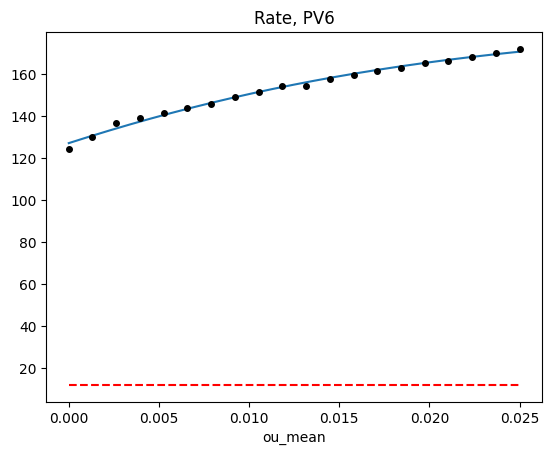

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from model_tuner.opt.map_funcs import MapFunc1DRichards, MapFitParams

#pop = 'CT6'
pop = 'PV6'

ou_mean = X['ou_mean'].sel(pop=pop)
rr = X['rate'].sel(pop=pop)

map_func = MapFunc1DRichards(y_limits=(0, np.inf))
fit_par = MapFitParams()
map_func.fit(ou_mean, rr)

r0 = target_rates[pop]
ou_mean_0 = map_func.apply_inv(r0)

ou_mean_max = ou_mean.max()
if not np.isnan(ou_mean_0):
    ou_mean_max = max(ou_mean_max, ou_mean_0)
ou_mean_hat = np.linspace(ou_mean.min(), ou_mean_max, 200)
rr_hat = map_func.apply(ou_mean_hat)

plt.figure()
plt.plot(ou_mean_hat, rr_hat)
plt.plot(ou_mean, rr, 'k.', markersize=8)
plt.plot(ou_mean_0, r0, 'r.', markersize=10)
plt.plot([ou_mean_hat.min(), ou_mean_hat.max()],
         [r0, r0], 'r--')
plt.xlabel('ou_mean')
plt.title(f'Rate, {pop}')

True